# Phase 1 — Data Loading & Inventory

**Well**: 15/9-F-1 A · **Field**: Volve, Norwegian North Sea  
**File**: `wells/15_9-F-1A.LAS`

This notebook covers the first phase of the log conditioning workflow:
- Load the LAS file and inspect the well header
- Inventory the available curve suite
- Assess data coverage (depth range and null fraction per curve)
- Load formation tops from the Volve picks database
- Display a standard 5-track composite log over the main logging interval

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────────────────
WELL_FILE = Path('../wells/15_9-F-1A.LAS')
TOPS_FILE = Path('../wells/Volve_formation_tops.csv')

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.linewidth'   : 0.8,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'figure.dpi'       : 120,
})

## Step 1.1 — Load LAS File

`lasio` reads LAS 2.0 files and returns a `LASFile` object. The `.df()` method returns a `pandas.DataFrame` with depth as the index.

The null value in this file is `−999.25` (CWLS standard). We replace it with `NaN` immediately so that pandas statistics and matplotlib ignore null samples automatically.

In [2]:
las = lasio.read(WELL_FILE)

# ── Well header ─────────────────────────────────────────────────────────────
header_items = [
    ('Well',     las.well['WELL'].value),
    ('Field',    las.well['FLD'].value),
    ('Company',  las.well['COMP'].value),
    ('Start (m)',las.well['STRT'].value),
    ('Stop (m)', las.well['STOP'].value),
    ('Step (m)', las.well['STEP'].value),
    ('Null',     las.well['NULL'].value),
    ('Location', las.well['LOC'].value),
    ('Lat',      las.well['LATI'].value),
    ('Long',     las.well['LONG'].value),
]
print('─' * 45)
print('  WELL HEADER')
print('─' * 45)
for k, v in header_items:
    print(f'  {k:<12s}: {v}')
print('─' * 45)

─────────────────────────────────────────────
  WELL HEADER
─────────────────────────────────────────────
  Well        : 15/9-F-1 A
  Field       : VOLVE
  Company     : Statoil Petroleum AS
  Start (m)   : 145.9
  Stop (m)    : 3681.9
  Step (m)    : 0.1
  Null        : -999.25
  Location    : Maersk Inspirer
  Lat         : 058 26' 29.907" N    DMS
  Long        : 001 53' 14.708" E    DMS
─────────────────────────────────────────────


## Step 1.2 — Curve Inventory

In [3]:
rows = []
for curve in las.curves:
    rows.append({'Mnemonic': curve.mnemonic, 'Units': curve.unit, 'Description': curve.descr})

inventory = pd.DataFrame(rows)
print(f"Total curves loaded: {len(inventory)}\n")
print(inventory.to_string(index=False))

Total curves loaded: 20

Mnemonic   Units Description
   DEPTH       M    0  Depth
ABDCQF01   g/cm3          v1
ABDCQF02   g/cm3          v1
ABDCQF03   g/cm3          v1
ABDCQF04   g/cm3          v1
      BS  inches          v1
    CALI  inches          v1
    DRHO   g/cm3          v1
      DT   us/ft          v1
     DTS   us/ft          v1
      GR     API          v1
    NPHI     v/v          v1
     PEF  b/elec          v1
  RACEHM UNKNOWN          v1
  RACELM UNKNOWN          v1
    RHOB   g/cm3          v1
     ROP    m/hr          v1
  RPCEHM UNKNOWN          v1
  RPCELM UNKNOWN          v1
      RT   ohm.m          v1


## Step 1.3 — Data Coverage Assessment

In [4]:
df = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.index.name = 'DEPTH'

total = len(df)
cov_rows = []
for col in df.columns:
    valid   = df[col].dropna()
    n_valid = len(valid)
    z_top   = valid.index[0]  if n_valid else np.nan
    z_bot   = valid.index[-1] if n_valid else np.nan
    cov_rows.append({
        'Curve'    : col,
        'Top (m)'  : z_top,
        'Base (m)' : z_bot,
        'N valid'  : n_valid,
        'Coverage' : f"{100 * n_valid / total:.1f}%" if n_valid else '—',
        'Mean'     : f"{valid.mean():.3f}" if n_valid else '—',
        'Min'      : f"{valid.min():.3f}"  if n_valid else '—',
        'Max'      : f"{valid.max():.3f}"  if n_valid else '—',
    })

print(pd.DataFrame(cov_rows).to_string(index=False))

   Curve  Top (m)  Base (m)  N valid Coverage    Mean    Min       Max
ABDCQF01   2609.7    3659.8    10502    29.7%   2.481  1.933     3.165
ABDCQF02   2609.7    3659.8    10502    29.7%   2.485  1.952     3.066
ABDCQF03   2609.7    3659.8    10502    29.7%   2.489  1.942     3.268
ABDCQF04   2609.7    3660.0    10504    29.7%   2.484  1.967     2.940
      BS    145.9    3681.9    35361   100.0%  17.887  8.500    36.000
    CALI   2585.0    3659.4    10745    30.4%   8.609  7.938     9.741
    DRHO   2595.4    3660.0    10647    30.1%   0.050 -0.103     0.128
      DT   2619.8    3642.1    10224    28.9%  76.678 56.382   116.232
     DTS   2619.8    3641.8    10214    28.9% 140.354 96.901   217.970
      GR    197.9    3674.4    34671    98.0%  58.277  0.149   587.017
    NPHI   2605.0    3657.3    10524    29.8%   0.170  0.029     0.593
     PEF   2605.0    3660.0    10551    29.8%   6.814  4.298    10.758
  RACEHM    226.0    3673.2    34211    96.7%   1.868  0.196  5464.369
  RACE

## Step 1.4 — Rock Physics Curve Availability Check

In [5]:
REQUIRED = {
    'GR'   : ('Gamma ray — lithology indicator',               True),
    'CALI' : ('Caliper — borehole QC',                         True),
    'BS'   : ('Bit size — caliper reference',                  True),
    'RHOB' : ('Bulk density — elastic input',                  True),
    'DRHO' : ('Density correction — RHOB quality',             True),
    'NPHI' : ('Neutron porosity — lithology / density infill', True),
    'DT'   : ('Compressional sonic → Vp',                     True),
    'DTS'  : ('Shear sonic → Vs  (RPM calibration)',           True),
    'RT'   : ('True resistivity — Rw / saturation / Faust',   True),
    'PEF'  : ('Photoelectric factor — mineral ID',             False),
}

print(f"{'Curve':<8}  {'Present':<12}  {'Critical':<10}  Role")
print('─' * 72)
for mnem, (role, critical) in REQUIRED.items():
    present = mnem in df.columns and df[mnem].notna().any()
    flag    = '✓' if present else '✗  ← MISSING'
    crit    = 'Critical' if critical else 'Optional'
    print(f"{mnem:<8}  {flag:<12}  {crit:<10}  {role}")

Curve     Present       Critical    Role
────────────────────────────────────────────────────────────────────────
GR        ✓             Critical    Gamma ray — lithology indicator
CALI      ✓             Critical    Caliper — borehole QC
BS        ✓             Critical    Bit size — caliper reference
RHOB      ✓             Critical    Bulk density — elastic input
DRHO      ✓             Critical    Density correction — RHOB quality
NPHI      ✓             Critical    Neutron porosity — lithology / density infill
DT        ✓             Critical    Compressional sonic → Vp
DTS       ✓             Critical    Shear sonic → Vs  (RPM calibration)
RT        ✓             Critical    True resistivity — Rw / saturation / Faust
PEF       ✓             Optional    Photoelectric factor — mineral ID


## Step 1.5 — Formation Tops

Formation tops are loaded from the Volve public picks database (`Volve_formation_tops.csv`). Depths are in **measured depth (MD)** to match the LAS file depth index.

Note that 15/9-F-1 A is a deviated well — the difference between MD and TVD is significant below ~2600 m (see the DEPTH vs TVD columns). All log displays use MD.

In [6]:
# ── Load picks and filter to F-1A ───────────────────────────────────────────
all_tops = pd.read_csv(TOPS_FILE)
f1a_tops = (
    all_tops[all_tops['WELL'] == 'NO 15/9-F-1 A']
    [['PICKS', 'DEPTH', 'TVD', 'TVDSS']]
    .sort_values('DEPTH')
    .reset_index(drop=True)
)
print(f"Formation tops for 15/9-F-1 A ({len(f1a_tops)} picks):\n")
print(f"  {'Formation':<35}  {'MD (m)':>8}  {'TVD (m)':>8}  {'TVDSS (m)':>10}")
print('  ' + '─' * 65)
for _, row in f1a_tops.iterrows():
    print(f"  {row['PICKS']:<35}  {row['DEPTH']:>8.1f}  {row['TVD']:>8.1f}  {row['TVDSS']:>10.1f}")

# ── Build a dict of {short_name: MD_depth} for the logging interval ─────────
# Clean up pick names to concise labels for the log display
TOPS_MD = {
    'Ty Fm'        : 2621.5,
    'Shetland GP'  : 2770.6,
    'Hod Fm'       : 2987.0,
    'Draupne Fm'   : 3358.0,
    'Heather Fm'   : 3429.4,
    'Hugin Fm'     : 3435.0,   # Volve reservoir
    'Sleipner Fm'  : 3500.2,
    'Skagerrak Fm' : 3543.7,
    'Smith Bank Fm': 3608.0,
}

# Mark the reservoir top — displayed with a distinct colour
RESERVOIR_TOP = 'Hugin Fm'

Formation tops for 15/9-F-1 A (15 picks):

  Formation                              MD (m)   TVD (m)   TVDSS (m)
  ─────────────────────────────────────────────────────────────────
  NORDLAND GP. Top                        146.0     146.0       -91.1
  Seabed                                  146.0     146.0       -91.1
  Utsira Fm. Top                          886.5     882.6      -827.7
  HORDALAND GP. Top                      1069.3    1062.8     -1007.9
  Ty Fm. Top                             2621.5    2473.6     -2418.7
  SHETLAND GP. Top                       2770.6    2605.7     -2550.8
  Ekofisk Fm. Top                        2770.6    2605.7     -2550.8
  Hod Fm. Top                            2987.0    2788.3     -2733.4
  Draupne Fm. Top                        3358.0    3008.7     -2953.8
  Heather Fm. Sand VOLVE Top             3429.4    3058.1     -3003.2
  Heather Fm. Top                        3429.4    3058.1     -3003.2
  Hugin Fm. VOLVE Top                    3435.0  

---

## Standard Composite Log Display

Five-track display. Tracks with two curves use **separate x-axis scales**: the primary curve's scale runs along the **top** of the track; the secondary curve's scale runs along the **bottom**. Track 4 (DT + DTS) shares a single reversed scale as both sonics are in the same units and overlapping range.

| Track | Top scale | Bottom scale | Convention |
|-------|-----------|--------------|------------|
| 1 | GR: 0–150 API | CALI / BS: 6–16 in | Sand fill gold; shale fill green |
| 2 | RT: 0.2–2000 Ω·m (log) | — | Dark red; log scale critical |
| 3 | RHOB: 1.95–2.95 g/cc | NPHI: 0.45–−0.15 v/v | Red top / blue bottom; NPHI reversed |
| 4 | DT + DTS: 300–40 μs/ft (shared, reversed) | — | Navy / crimson; fast rock → right |
| 5 | DRHO: −0.5–0.5 g/cc | — | Purple; ±0.15 threshold lines |

Formation tops are shown as dashed lines across all tracks, labelled on the left of track 1.

In [7]:
def plot_composite_log(
    df, top, base,
    well_name    = 'Well',
    bs_default   = 8.5,
    tops         = None,    # dict  {name: depth_MD}  or None
    reservoir_top= None,    # name of reservoir top — drawn in blue
    figsize      = (16, 14),
):
    """
    Standard 5-track composite well log display.

    Dual-curve tracks use separate x-axis scales:
      - Primary curve scale at TOP  of track
      - Secondary curve scale at BOTTOM of track
    Track 4 (DT / DTS) shares one reversed scale.

    Parameters
    ----------
    df            : DataFrame, DEPTH as index, nulls = NaN
    top, base     : Depth window to display (m MD)
    well_name     : Figure title string
    bs_default    : Bit size (inches) used where BS curve is absent / surface value
    tops          : dict {formation_name: depth_MD} — draws lines + labels
    reservoir_top : key from `tops` dict to highlight in a distinct colour
    figsize       : (width, height) in inches
    """
    sub   = df.loc[top:base]
    depth = sub.index.values

    def get(col):
        return sub[col].values if col in sub.columns else np.full(len(depth), np.nan)

    gr   = get('GR')
    cali = get('CALI')
    bs   = get('BS')
    rt   = get('RT')
    rhob = get('RHOB')
    nphi = get('NPHI')
    dt   = get('DT')
    dts  = get('DTS')
    drho = get('DRHO')

    bs_plot = np.where(np.isnan(bs) | (bs > 30), bs_default, bs)

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 5, figsize=figsize, sharey=True,
        gridspec_kw={'width_ratios': [1.4, 1.0, 1.4, 1.4, 0.9]},
    )
    # Use subplots_adjust (not tight_layout) so bottom twin-axis labels
    # and top track titles have guaranteed space
    fig.subplots_adjust(top=0.93, bottom=0.07, left=0.07, right=0.98, wspace=0.07)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def style_top_axis(ax, label, color, xlim, log=False):
        """Configure the primary (top) x-axis of a track."""
        if log:
            ax.set_xscale('log')
        ax.set_xlim(*xlim)
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        ax.set_xlabel(label, color=color, fontsize=8, labelpad=3)
        ax.tick_params(axis='x', colors=color, labelsize=7, length=4)

    def add_bottom_axis(ax, label, color, xlim, log=False):
        """Add a secondary (bottom) x-axis twin to a track."""
        ax2 = ax.twiny()
        if log:
            ax2.set_xscale('log')
        ax2.set_xlim(*xlim)
        ax2.xaxis.set_ticks_position('bottom')
        ax2.xaxis.set_label_position('bottom')
        ax2.spines['bottom'].set_visible(True)
        ax2.spines['top'].set_visible(False)
        ax2.set_xlabel(label, color=color, fontsize=8, labelpad=3)
        ax2.tick_params(axis='x', colors=color, labelsize=7,
                        length=4, top=False, bottom=True)
        return ax2

    # ─────────────────────────────────────────────────────────────────────────
    # Track 1 — Gamma Ray (top) + Caliper / BS (bottom)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0]
    GR_CUT = 60
    ax.plot(gr, depth, color='#4A7C40', lw=0.9)
    ax.fill_betweenx(depth, gr, GR_CUT,
                     where=(gr < GR_CUT), color='#F5C518', alpha=0.55)
    ax.fill_betweenx(depth, GR_CUT, gr,
                     where=(gr >= GR_CUT), color='#7FB069', alpha=0.20)
    style_top_axis(ax, 'GR (API)', '#4A7C40', (0, 150))

    ax_cal = add_bottom_axis(ax, 'CALI / BS (in)', '#333333', (6, 16))
    ax_cal.plot(cali,    depth, color='#1A1A1A', lw=0.8, ls='--')
    ax_cal.plot(bs_plot, depth, color='#888888', lw=0.8, ls=':')

    ax.set_ylabel('Depth (m MD)', fontsize=10)
    ax.set_title('GR  |  CALI', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.invert_yaxis()   # shared — inverts all 5 tracks

    # ─────────────────────────────────────────────────────────────────────────
    # Track 2 — Resistivity  (single scale, top)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(rt, depth, color='#8B0000', lw=0.8)
    style_top_axis(ax, 'RT (Ω·m)', '#8B0000', (0.2, 2000), log=True)
    ax.set_yticklabels([])
    ax.set_title('RESISTIVITY', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5, which='both')

    # ─────────────────────────────────────────────────────────────────────────
    # Track 3 — Density / RHOB (top, red)  +  Neutron / NPHI (bottom, blue)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[2]
    RHOB_MIN, RHOB_MAX = 1.95, 2.95
    NPHI_HI,  NPHI_LO  = 0.45, -0.15   # reversed: high value on left

    ax.plot(rhob, depth, color='#C0392B', lw=0.9)
    style_top_axis(ax, 'RHOB (g/cc)', '#C0392B', (RHOB_MIN, RHOB_MAX))

    ax_nphi = add_bottom_axis(ax, 'NPHI (v/v)  ←  0.45', '#2980B9', (NPHI_HI, NPHI_LO))
    ax_nphi.plot(nphi, depth, color='#2980B9', lw=0.9)

    # Gas crossover fill (NPHI mapped onto RHOB axis space)
    nphi_mapped = RHOB_MIN + (NPHI_HI - nphi) / (NPHI_HI - NPHI_LO) * (RHOB_MAX - RHOB_MIN)
    ax.fill_betweenx(depth, rhob, nphi_mapped,
                     where=(nphi_mapped < rhob), color='#85C1E9', alpha=0.35)

    ax.set_yticklabels([])
    ax.set_title('RHOB  |  NPHI', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ─────────────────────────────────────────────────────────────────────────
    # Track 4 — DT + DTS  (shared reversed scale, top only)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[3]
    ax.plot(dt,  depth, color='#1B2631', lw=0.9, label='DT')
    ax.plot(dts, depth, color='#E74C3C', lw=0.9, label='DTS', alpha=0.85)
    style_top_axis(ax, 'DT / DTS  (μs/ft)  →fast', '#333333', (300, 40))
    ax.legend(loc='lower right', fontsize=7, framealpha=0.7)
    ax.set_yticklabels([])
    ax.set_title('DT  |  DTS', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ─────────────────────────────────────────────────────────────────────────
    # Track 5 — DRHO  (single scale, top)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[4]
    THRESH = 0.15
    ax.plot(drho, depth, color='#7D3C98', lw=0.8)
    ax.fill_betweenx(depth, drho, 0,
                     where=(np.abs(drho) > THRESH),  color='#E74C3C', alpha=0.40)
    ax.fill_betweenx(depth, drho, 0,
                     where=(np.abs(drho) <= THRESH), color='#7D3C98', alpha=0.12)
    ax.axvline(0,      color='#555555', lw=0.7)
    ax.axvline( THRESH, color='#E74C3C', lw=0.8, ls='--')
    ax.axvline(-THRESH, color='#E74C3C', lw=0.8, ls='--')
    style_top_axis(ax, 'DRHO (g/cc)', '#7D3C98', (-0.5, 0.5))
    ax.text(0.97, 0.01, f'|DRHO|>{THRESH}\n= flag',
            transform=ax.transAxes, fontsize=6, ha='right', va='bottom',
            color='#E74C3C')
    ax.set_yticklabels([])
    ax.set_title('DRHO', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ── Depth axis ticks ─────────────────────────────────────────────────────
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(100))
    axes[0].yaxis.set_minor_locator(ticker.MultipleLocator(50))
    axes[0].tick_params(axis='y', which='major', length=5)
    axes[0].tick_params(axis='y', which='minor', length=3)

    # ── Formation tops ────────────────────────────────────────────────────────
    if tops:
        # Blended transform: x in axes fraction, y in depth (data) coordinates
        label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)

        for name, depth_md in tops.items():
            if not (top <= depth_md <= base):
                continue   # outside display window

            is_reservoir = (name == reservoir_top)
            line_color   = '#1A5276' if is_reservoir else '#5D4E37'
            line_lw      = 1.0      if is_reservoir else 0.8

            # Dashed line across all tracks
            for ax in axes:
                ax.axhline(depth_md, color=line_color, lw=line_lw,
                           ls=(0, (7, 4)), alpha=0.85, zorder=4)

            # Formation label — left edge of track 1, just above the line
            axes[0].text(
                0.02, depth_md - (base - top) * 0.003,
                name,
                transform = label_trans,
                fontsize  = 6.5,
                va        = 'bottom',
                ha        = 'left',
                color     = line_color,
                fontweight= 'bold' if is_reservoir else 'normal',
                bbox      = dict(facecolor='white', alpha=0.75,
                                 edgecolor='none', pad=1.2),
                zorder    = 5,
            )

    # ── Title ─────────────────────────────────────────────────────────────────
    fig.suptitle(
        f'{well_name}  —  Composite Log Display  ({top:.0f}–{base:.0f} m MD)',
        fontsize=12, fontweight='bold',
    )

    return fig, axes

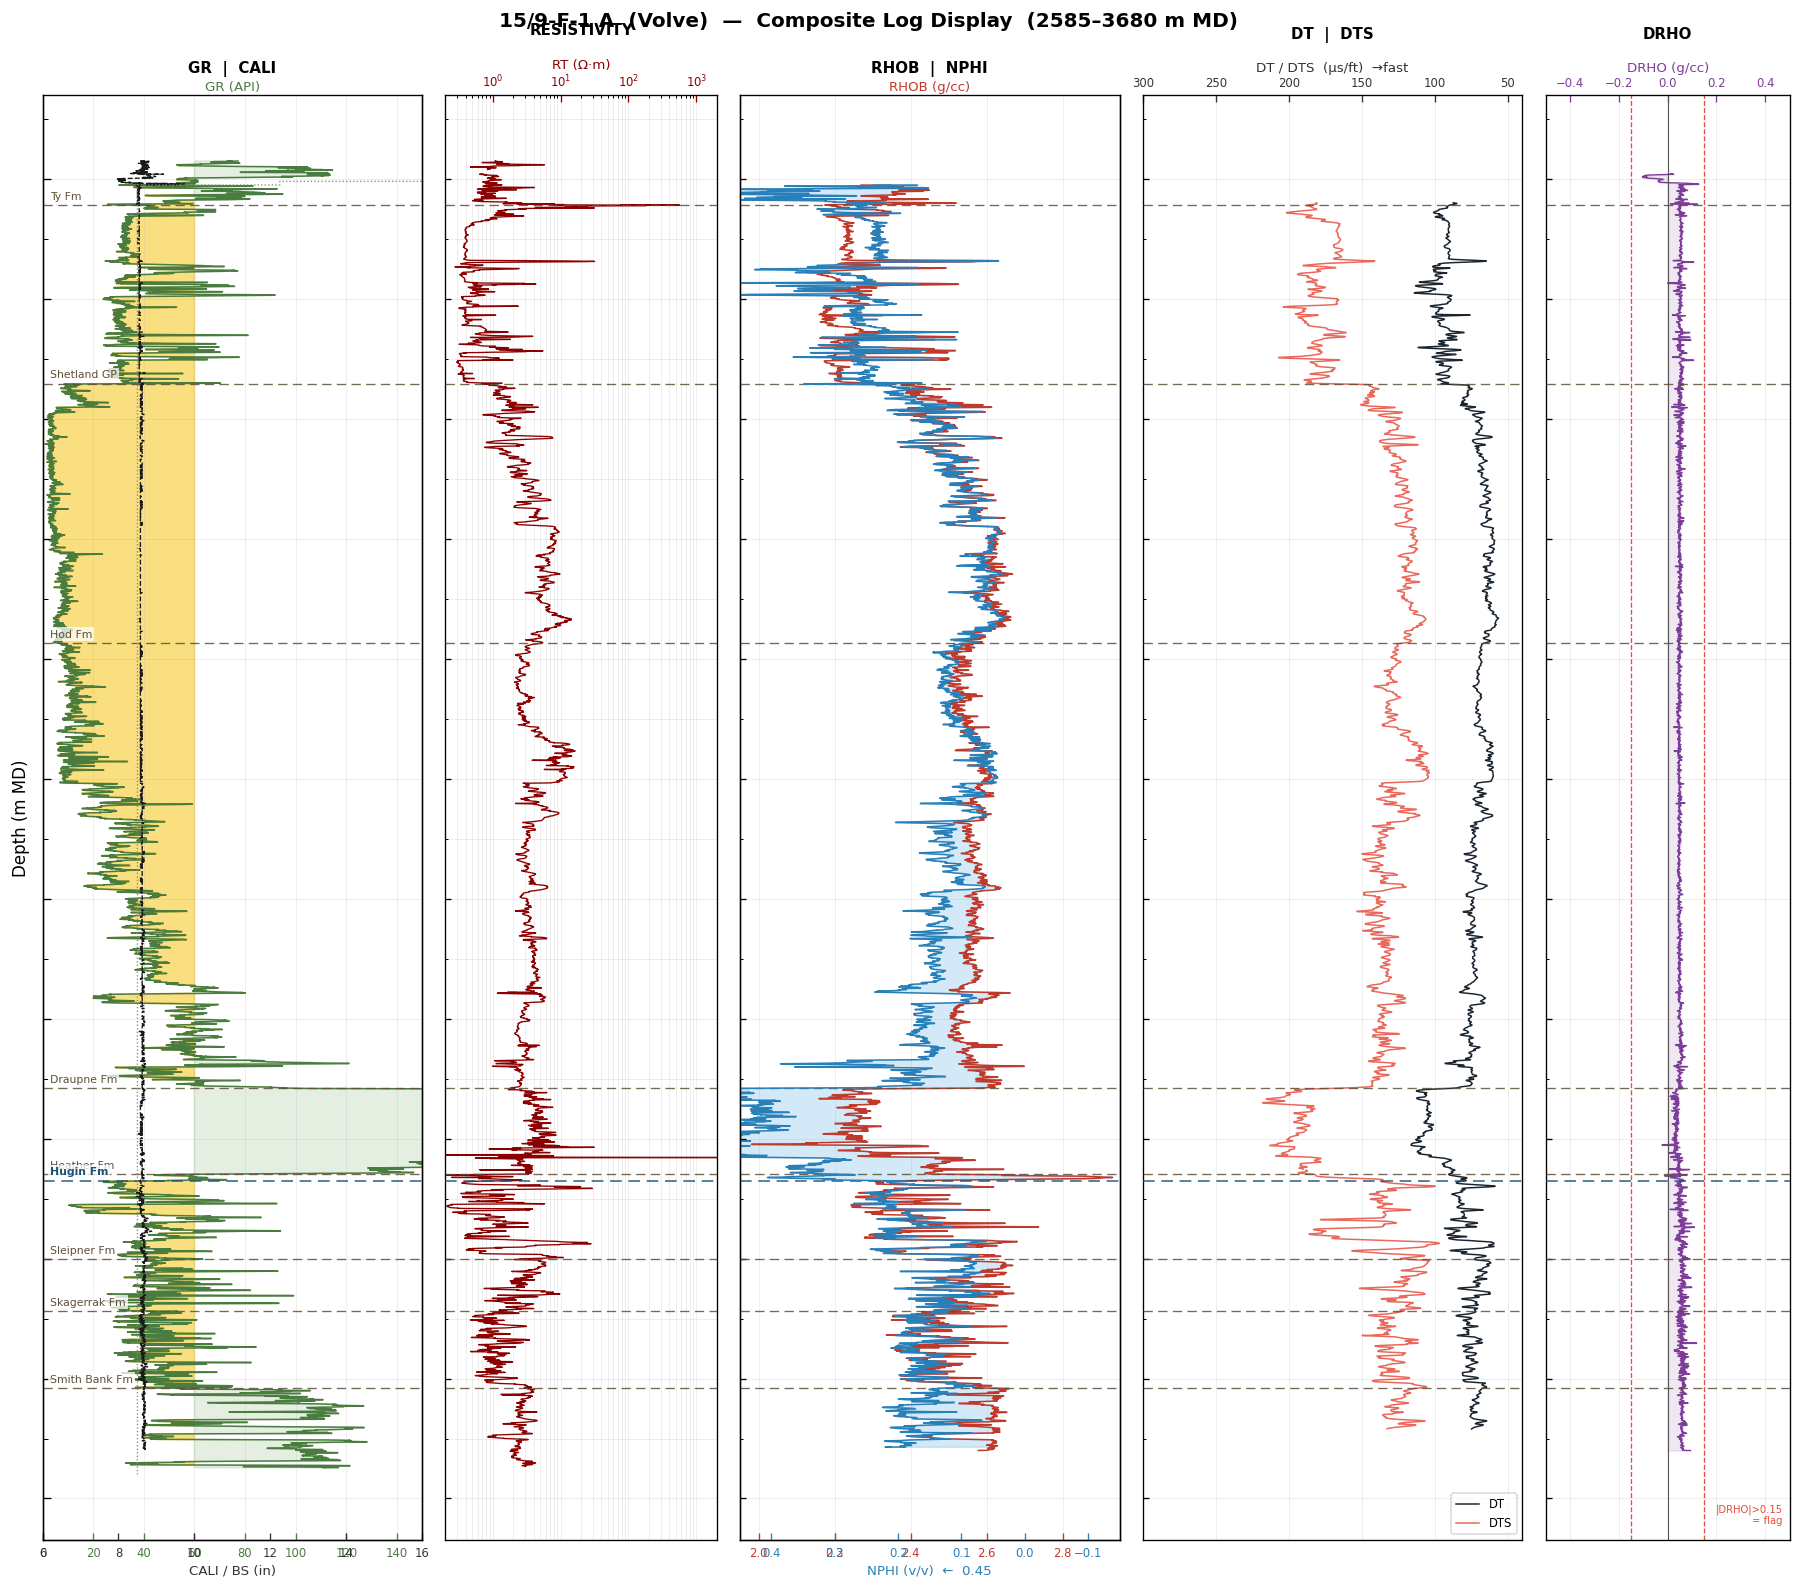

In [8]:
# ── Full logging interval ────────────────────────────────────────────────────
fig, axes = plot_composite_log(
    df,
    top           = 2585,
    base          = 3680,
    well_name     = '15/9-F-1 A  (Volve)',
    bs_default    = 8.5,
    tops          = TOPS_MD,
    reservoir_top = RESERVOIR_TOP,
)
plt.show()

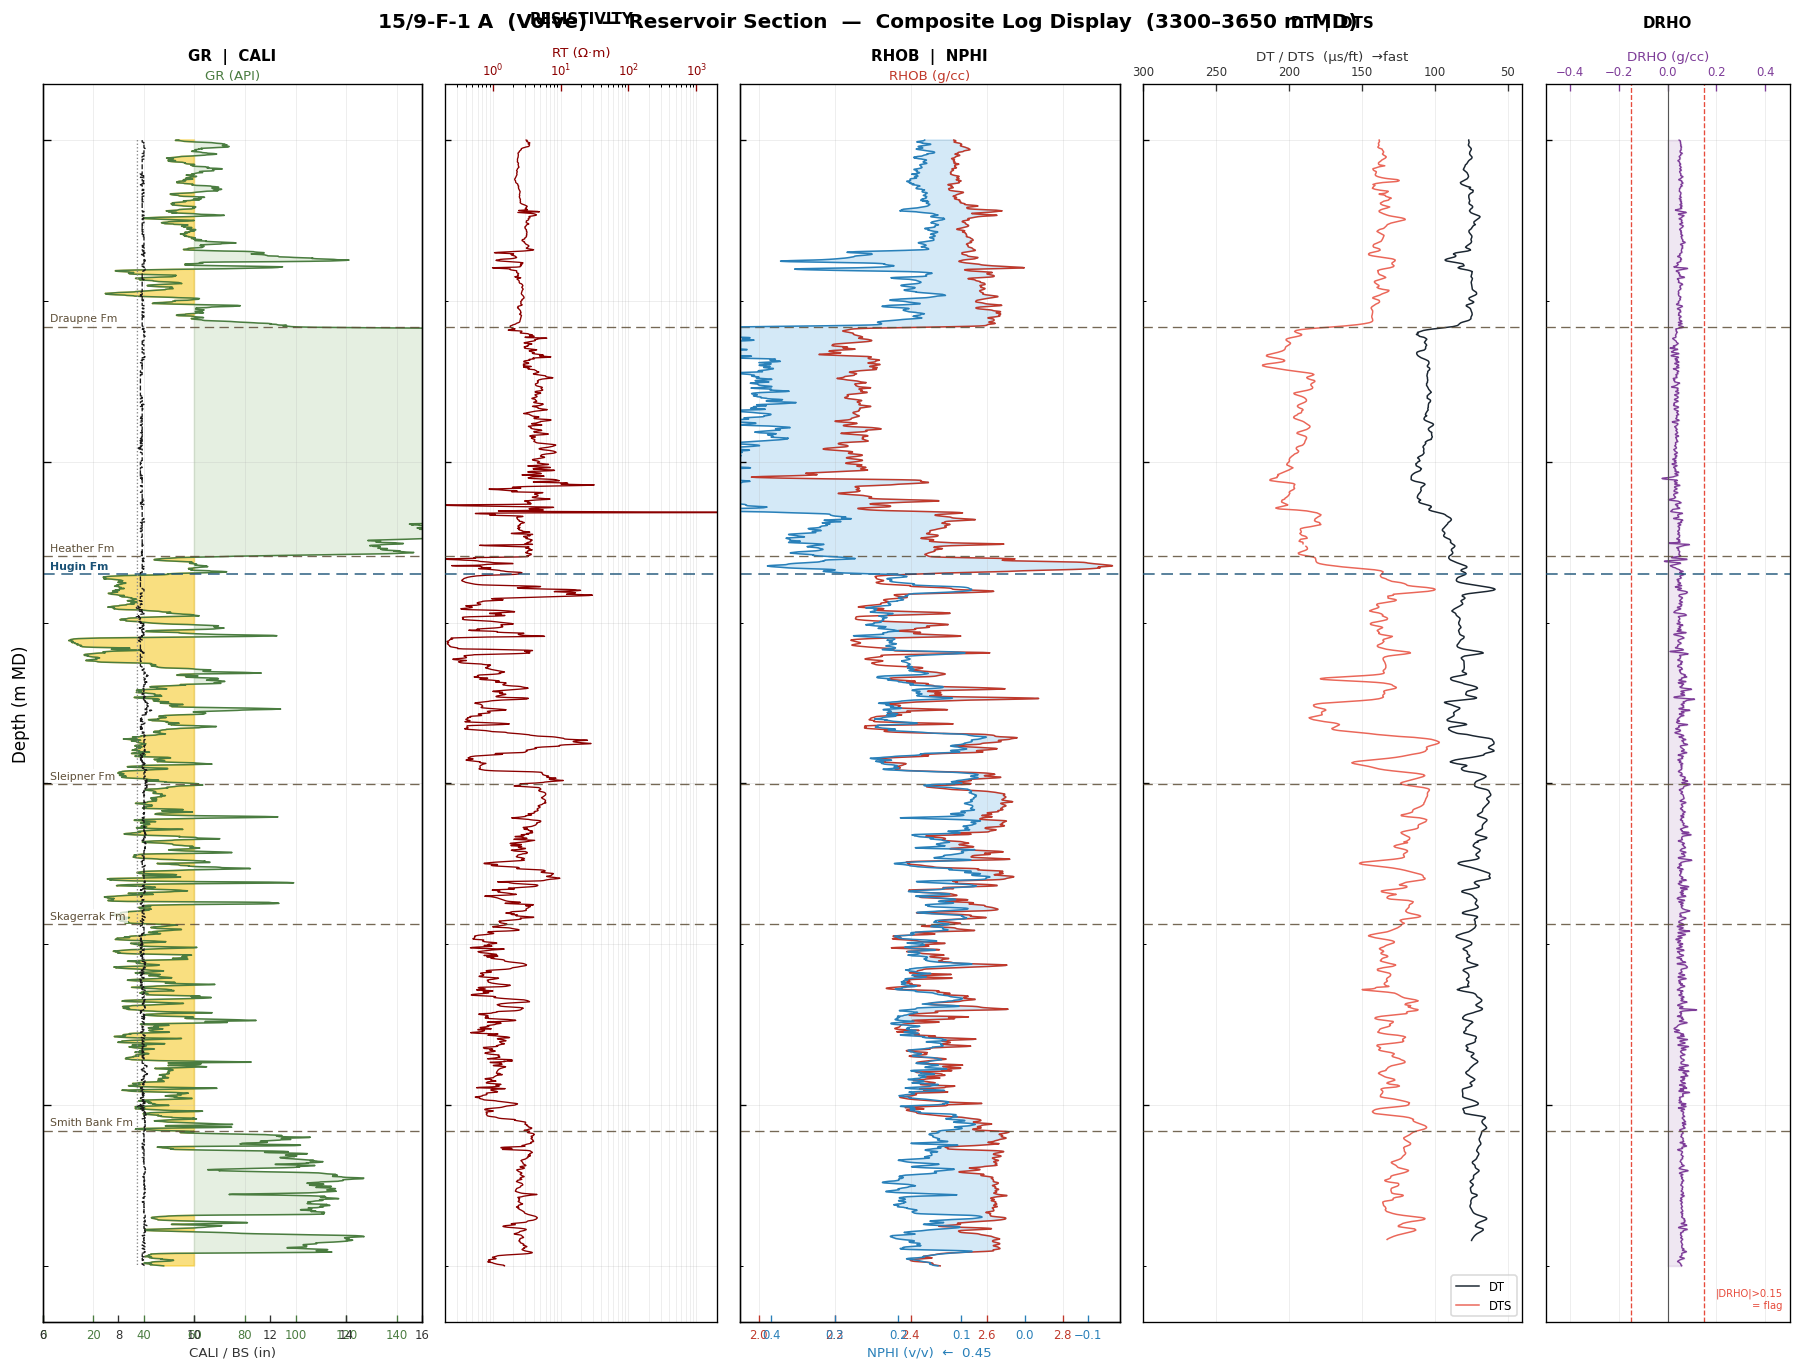

In [9]:
# ── Reservoir zoom — Draupne cap rock through Smith Bank ────────────────────
fig, axes = plot_composite_log(
    df,
    top           = 3300,
    base          = 3650,
    well_name     = '15/9-F-1 A  (Volve)  — Reservoir Section',
    bs_default    = 8.5,
    tops          = TOPS_MD,
    reservoir_top = RESERVOIR_TOP,
    figsize       = (16, 12),
)
plt.show()

## Step 1.6 — Observations from the Composite Display

**Track 1 — GR / Caliper**
- GR shows a cyclical sand-shale pattern consistent with alternating reservoir and seal facies
- Clean sand intervals (GR < 60 API, gold fill) identify potential reservoir zones — note the Hugin Fm sandstone below 3435 m MD
- CALI tracks very close to bit size (8.5") throughout → good hole condition; no significant washouts
- Very high GR spikes (>200 API) in the Draupne Fm shale — consistent with the organic-rich cap rock

**Track 2 — Resistivity**
- High RT spikes (>100 Ω·m) in the clean sand intervals of the Hugin Fm → hydrocarbon saturation in the reservoir
- Low RT in the Draupne / Heather shales (~1–3 Ω·m) defines the brine baseline for Rw estimation
- The Hod Fm chalk section (~2987 m) shows moderate elevated RT characteristic of tight carbonate

**Track 3 — RHOB / NPHI**
- Blue crossover shading visible in Hugin Fm sands → light hydrocarbons (gas/condensate) confirmed by simultaneous high RT
- The Draupne shale shows the classic high-NPHI (clay-bound water), moderate-RHOB shale signature
- PEF values are elevated throughout (mean ~6.8 b/e) — check whether barite mud or K-feldspar-rich sands are affecting the measurement

**Track 4 — DT / DTS**
- Both DT and DTS present — confirms 15/9-F-1 A as the Vs calibration well for the rock physics model
- DT maximum of 116 μs/ft is within the physically plausible range; no obvious cycle skips requiring repair
- DTS/DT divergence (widening gap) in the Hugin Fm sands is consistent with gas — compressional velocity is more sensitive to gas saturation than shear velocity

**Track 5 — DRHO**
- DRHO maximum ~0.13 g/cc — stays within the ±0.15 threshold throughout; no intervals requiring density replacement
- A few narrow positive DRHO excursions correlate with the tightest caliper excursions — consistent with minor pad bridging

**Formation tops**
- The Hugin Fm top (3435 m MD, blue line) aligns precisely with the onset of: low GR, high RT, NPHI–RHOB crossover, and DT–DTS divergence → all four elastic/petrophysical indicators confirm the reservoir top

---
## Phase 1 Summary

| Item | Status |
|------|--------|
| LAS loaded, nulls replaced | ✓ |
| Well header documented | ✓ |
| Curve inventory complete | ✓ |
| Data coverage assessed | ✓ |
| Required rock physics curves present | ✓ All present (incl. DTS) |
| Formation tops loaded (9 picks in logging interval) | ✓ |
| Composite display with tops generated | ✓ |
| Visual QC observations noted | ✓ |

**Next**: Notebook `02_temperature_pressure.ipynb` — derive the geothermal gradient, Rw, and pressure logs (Phase 2).